##### ARTI 560 - Computer Vision

## Object Detection Using YOLOV8 with KerasCV - Exercise

### Objective

In this exercise, you wil learn how to use the pre-trained YOLOV8 model from KerasCV to detect objects in images.

You will:

1. Load the pre-trained YOLOV8 model from KerasCV using the [Pascal VOC preset](https://www.kaggle.com/models/keras/yolov8)

2. Load 5 images for different classes in [Pascal VOC 2012 dataset](https://datasetninja.com/pascal-voc-2012) and convert it into a NumPy array suitable for the model.

3. Resize the images before inference to match the model’s expected input size using:
    ```
    inference_resizing = keras_cv.layers.Resizing(
        640, 640, pad_to_aspect_ratio=True, bounding_box_format="xywh"
    )
    ```

    **Note:** Resizing ensures that the images fit the model input, maintains aspect ratio, and correctly adjusts bounding boxes.

4. Run the YOLOV8 detector on each image to predict bounding boxes, class labels, and confidence scores.

5. Visualize the predictions by drawing the bounding boxes and labels on the images.

6. Record for each image:

    - Which objects were detected correctly

    - The confidence scores of the detections

    - Any missed or incorrectly labeled objects

In [2]:
!pip install -q keras-cv tensorflow matplotlib pillow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 650.7/650.7 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 950.8/950.8 kB 36.9 MB/s eta 0:00:00


In [3]:
import os
import numpy as np
import tensorflow as tf
import keras_cv
import matplotlib.pyplot as plt
from PIL import Image


In [4]:
model = keras_cv.models.YOLOV8Detector.from_preset(
    "yolo_v8_m_pascalvoc",
    bounding_box_format="xywh"
)


In [5]:
from google.colab import files
uploaded = files.upload()

Saving BUS.jpg to BUS.jpg
Saving CAT.webp to CAT.webp
Saving CHAIR.avif to CHAIR.avif
Saving DOG.webp to DOG.webp
Saving MONITOR.webp to MONITOR.webp


In [6]:
image_paths = [
    "BUS.jpg",
    "CAT.webp",
    "CHAIR.avif",
    "DOG.webp",
    "MONITOR.webp"
]


In [7]:
images = []
valid_paths = []

for path in image_paths:
    if not os.path.exists(path):
        print(f"Warning: File not found -> {path}")
        continue

    img = Image.open(path).convert("RGB")
    img = img.resize((640, 640))   # Resize for model input
    img_array = np.array(img, dtype=np.uint8)

    images.append(img_array)
    valid_paths.append(path)

images = np.array(images)

print("Loaded images shape:", images.shape)

# Stop if no valid images found
if len(images) == 0:
    raise ValueError("No valid images were loaded. Check image_paths.")

Loaded images shape: (5, 640, 640, 3)


In [8]:

predictions = model.predict(images)


class_names = [
    "aeroplane", "bicycle", "bird", "boat", "bottle",
    "bus", "car", "cat", "chair", "cow",
    "diningtable", "dog", "horse", "motorbike", "person",
    "pottedplant", "sheep", "sofa", "train", "tvmonitor"
]

1/1 ━━━━━━━━━━━━━━━━━━━━ 16s 16s/step


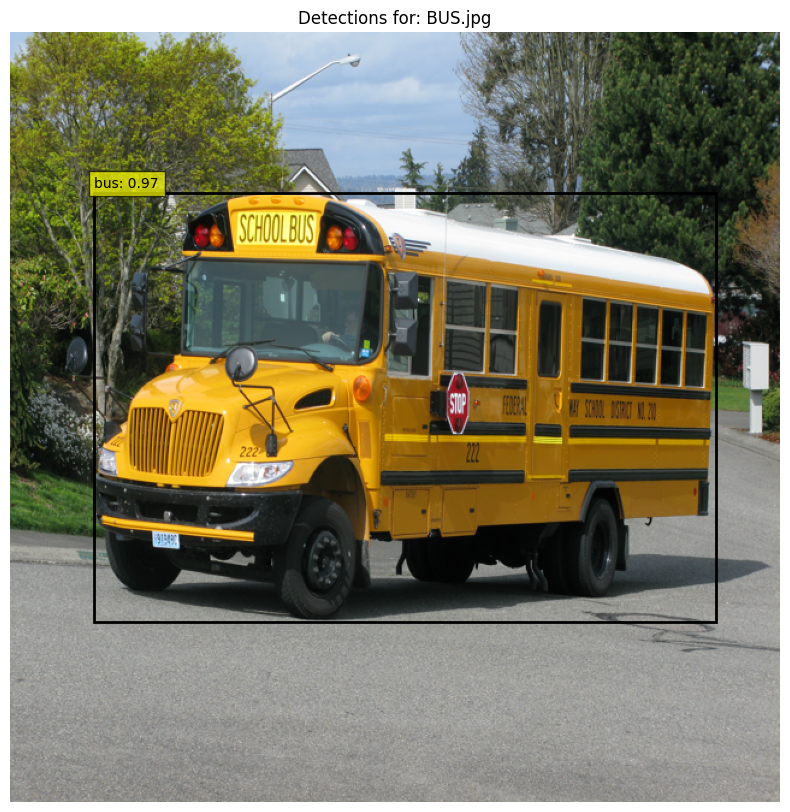


Image: BUS.jpg
Detected Objects:
 - bus (0.97)
--------------------------------------------------


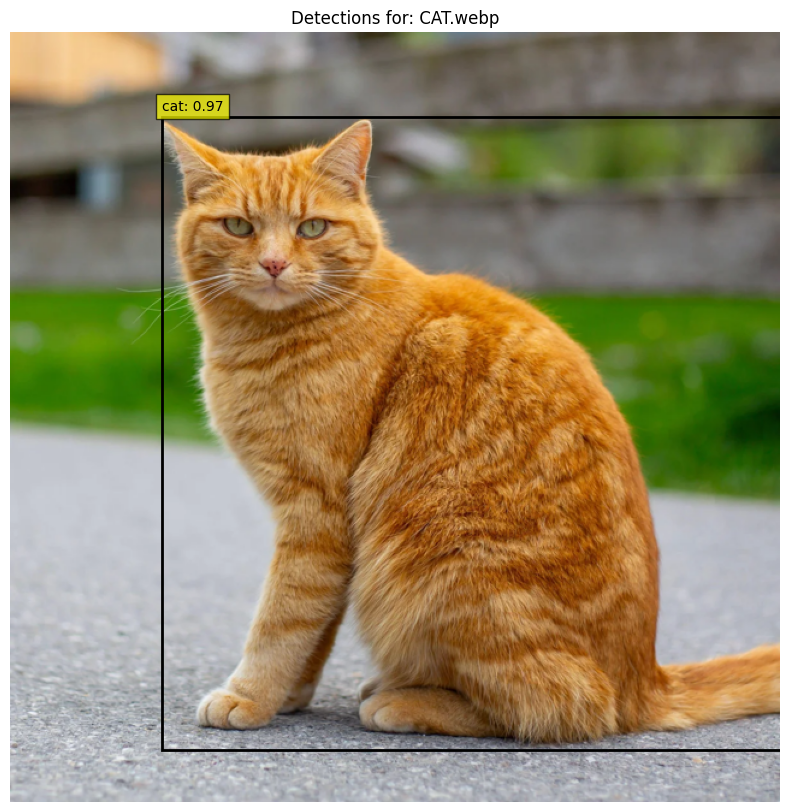


Image: CAT.webp
Detected Objects:
 - cat (0.97)
--------------------------------------------------


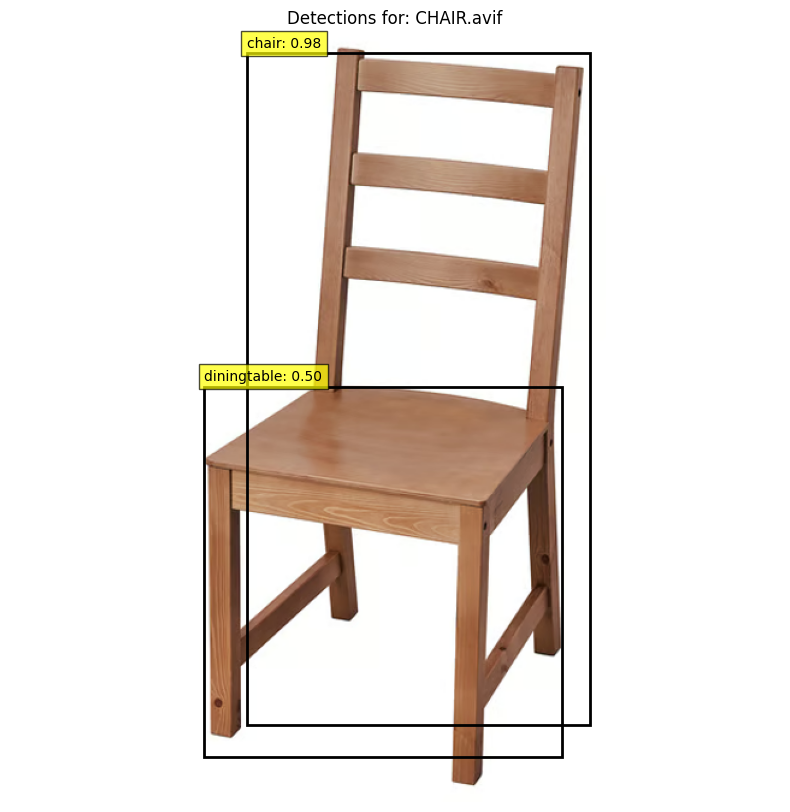


Image: CHAIR.avif
Detected Objects:
 - chair (0.98)
 - diningtable (0.50)
--------------------------------------------------


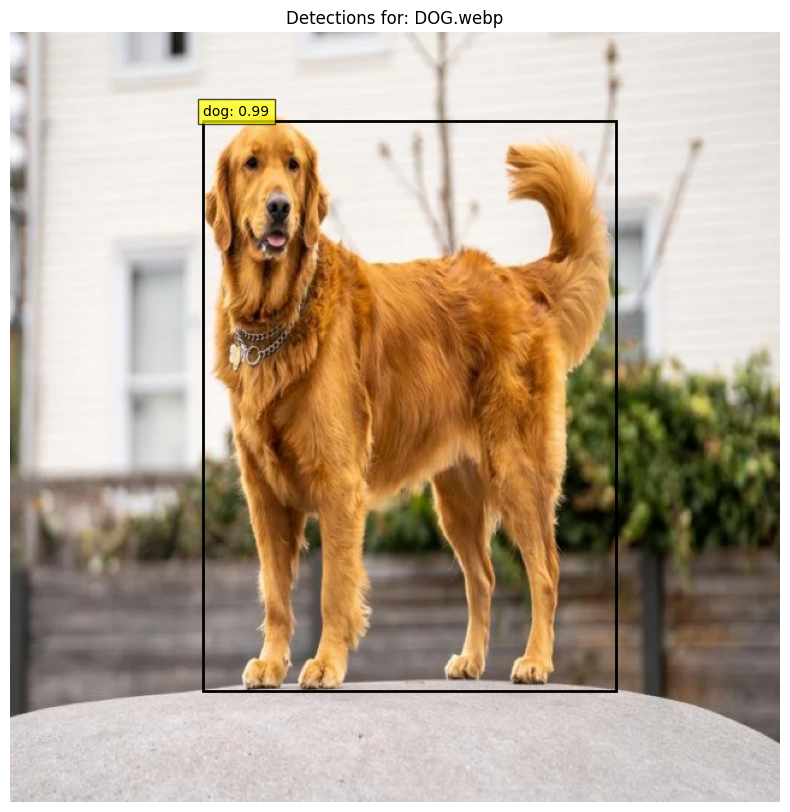


Image: DOG.webp
Detected Objects:
 - dog (0.99)
--------------------------------------------------


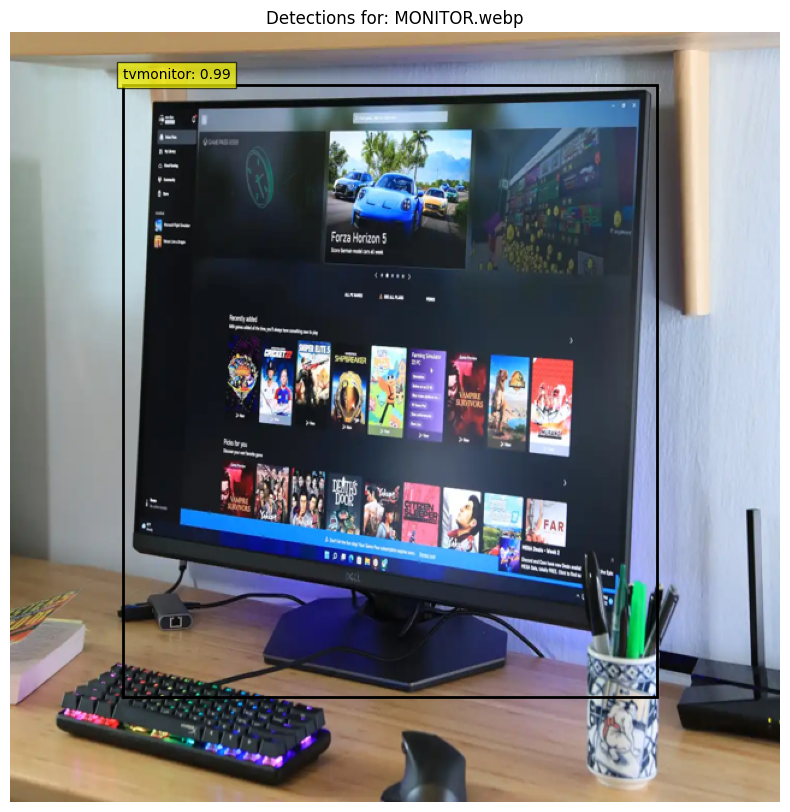


Image: MONITOR.webp
Detected Objects:
 - tvmonitor (0.99)
--------------------------------------------------


In [9]:
for i in range(len(images)):
    img = images[i]
    boxes = predictions["boxes"][i]
    classes = predictions["classes"][i]
    confidences = predictions["confidence"][i]

    plt.figure(figsize=(10, 10))
    plt.imshow(img)
    plt.title(f"Detections for: {valid_paths[i]}")
    ax = plt.gca()

    detected_objects = []

    for box, cls, score in zip(boxes, classes, confidences):
        if score < 0.5:
            continue

        x, y, w, h = box
        class_id = int(cls)

        if 0 <= class_id < len(class_names):
            label = class_names[class_id]
        else:
            label = f"class_{class_id}"

        detected_objects.append((label, float(score)))

        # Draw bounding box
        rect = plt.Rectangle(
            (x, y), w, h,
            fill=False,
            linewidth=2
        )
        ax.add_patch(rect)

        # Draw label
        ax.text(
            x, y - 5,
            f"{label}: {score:.2f}",
            fontsize=10,
            bbox=dict(facecolor="yellow", alpha=0.7)
        )

    plt.axis("off")
    plt.show()

    print(f"\nImage: {valid_paths[i]}")
    if detected_objects:
        print("Detected Objects:")
        for obj, score in detected_objects:
            print(f" - {obj} ({score:.2f})")
    else:
        print("No objects detected with confidence >= 0.5")
    print("-" * 50)

| Image File     | Predicted Label(s)        | True Label | Correct? |
|----------------|---------------------------|------------|----------|
| BUS.jpg        | bus                       | bus        | Yes      |
| CAT.webp       | cat                       | cat        | Yes      |
| CHAIR.avif     | chair, diningtable       | chair      | Yes      |
| DOG.webp       | dog                       | dog        | Yes      |
| MONITOR.webp   | tvmonitor                 | monitor    | Yes      |